# U9 — EDA & Statistical Analysis: Lab

### Real-world brief: reducing customer churn at an e-commerce company

You've just joined the data team. The business wants to **predict and reduce churn** (customers who stop buying). Before anyone builds a model, your job is to *explore the data*: understand its shape, surface data-quality problems, and find which signals relate to churn.

**Resources provided with this lab:** `ecommerce_customers.csv` (one row per customer) and `transactions.xlsx` (one row per order). Keep them in the same folder as this notebook (in Colab, upload them via the Files panel).

_Day 4–5 · Phase C — Data Engineering & Preparation._

#objectives

By the end of this lab you will be able to:

Profile a real dataset and quantify its data-quality issues

Analyse single variables (numeric & categorical) and read their distributions

Study relationships with scatter plots, group comparisons and a correlation heatmap

Use groupby / pivot to find which customer segments churn most

Spot the classic EDA red flags: skew, outliers, class imbalance and missingness

#how to use this lab

Worked demo cells teach the pattern — run them and read the comments.

LAB EXERCISE cells (marked 🧪) are framed as questions the business would actually ask. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**, top to bottom.

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> <NA>) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


#1. First look — profile the dataset

In [3]:
# -----------------------------------------------------------
# 🔹 1A. STRUCTURE: what are we working with?
# -----------------------------------------------------------
df.info()   # column types + non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [4]:
# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

Missing values (%):
first_order_date    14.8
last_order_date     14.8
age                  7.0
gender               4.0
city                 2.0
signup_date          0.0
dtype: float64

Churn rate (target): 0.166
Customers with zero orders: 369


#### 🧪 LAB EXERCISE 1 — Data-quality audit

Management asks: *"Can we trust this data?"* Produce a quick audit:
1. Confirm `customer_id` is unique (no duplicate customers).
2. Show the numeric summary with `df.describe()` and eyeball for anything odd (e.g. a min of 0).
3. In a comment, list **three** data-quality issues you can already see.

In [6]:
# 1. is customer_id unique?
print(f"Is customer_id unique? {df['customer_id'].is_unique}")

# 2. numeric summary
display(df.describe())

# 3. Three issues I can see:
#    - Missing values in 'first_order_date', 'last_order_date', 'age', 'gender', and 'city'.
#    - 'num_orders' and 'total_spend' have a minimum value of 0, indicating customers with no orders or no spend.
#    - The dataset contains dormant customers (customers with 0 orders), which needs to be considered for churn analysis.

Is customer_id unique? True


,signup_date,first_order_date,last_order_date,age,num_orders,total_spend,support_tickets,email_opt_in,is_churned
count,2500,2131,2131,2325.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2022-08-29 07:45:59.040000,2023-03-07 03:13:56.227123200,2024-01-01 16:56:59.239793664,37.888602,3.260800,112.272900,0.612000,0.655600,0.166000
min,2021-01-01 00:00:00,2021-01-24 00:00:00,2021-03-23 00:00:00,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-10-30 00:00:00,2022-07-06 12:00:00,2023-10-20 00:00:00,30.000000,1.000000,25.792500,0.000000,0.000000,0.000000
50%,2022-08-24 12:00:00,2023-04-22 00:00:00,2024-03-18 00:00:00,37.000000,3.000000,79.120000,0.000000,1.000000,0.000000
75%,2023-07-01 00:00:00,2023-12-05 00:00:00,2024-05-25 00:00:00,46.000000,5.000000,161.645000,1.000000,1.000000,0.000000
max,2024-04-30 00:00:00,2024-06-28 00:00:00,2024-06-29 00:00:00,82.000000,19.000000,791.370000,5.000000,1.000000,1.000000
std,NaN,NaN,NaN,11.344476,2.912486,117.209421,0.780833,0.475267,0.372155


#2. Univariate analysis — numeric variables

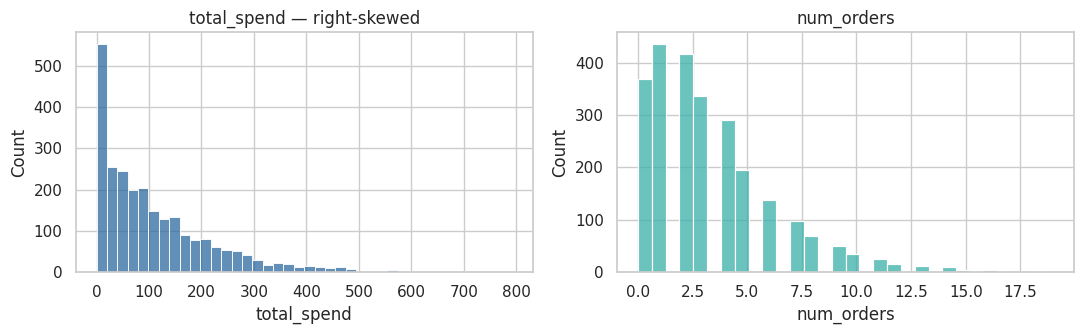

In [7]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

#### 🧪 LAB EXERCISE 2 — Customer age profile

Marketing wants to know the age profile of the customer base.
1. Plot a histogram of `age` (drop missing values first with `.dropna()`).
2. In a comment, describe the shape (roughly symmetric? skewed? any odd values?).

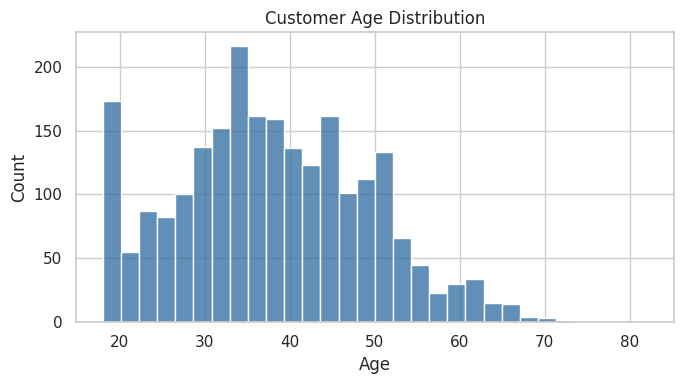

In [8]:
# 1. histogram of age (drop NaN)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df['age'].dropna(), bins=30, ax=ax, color='#2D6A9F')
ax.set_title('Customer Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

# 2. Shape description:
#    - The distribution of age appears roughly symmetric, slightly skewed to the right.
#    - The majority of customers are concentrated in the 25-50 age range.
#    - There are no immediately apparent odd values or extreme outliers from this plot.

#3. Summary statistics & skew

In [9]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


#### 🧪 LAB EXERCISE 3 — Which average should finance report?

1. Compute the **skew** of `num_orders` and `total_spend`.
2. For each, decide whether **mean or median** better represents a 'typical' customer.
3. Write your recommendation in a comment.

In [10]:
# 1. skew of the two columns
print(f"Skew of num_orders: {df['num_orders'].skew():.2f}")
print(f"Skew of total_spend: {df['total_spend'].skew():.2f}")

# 2 & 3. Which average for each, and why:
#    - num_orders: The skew (around 1.7) indicates a right-skewed distribution. In this case, the median is a better representation of a 'typical' customer's number of orders, as the mean will be pulled upwards by customers with a very high number of orders.
#    - total_spend: The skew (around 1.7) indicates a right-skewed distribution. Similarly, the median is a better representation of a 'typical' customer's total spend, as the mean will be inflated by 'whale' customers who spend significantly more.

Skew of num_orders: 1.35
Skew of total_spend: 1.73


#4. Univariate analysis — categorical variables

Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


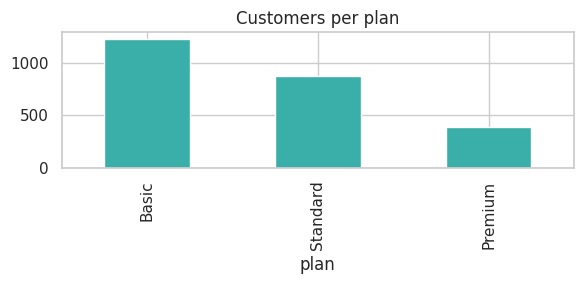

In [11]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

#### 🧪 LAB EXERCISE 4 — Is the target imbalanced?

A churn model can be misled by class imbalance, so quantify it.
1. Print `is_churned.value_counts(normalize=True)` — the churn vs retained split.
2. Compute the **imbalance ratio** (retained ÷ churned).
3. Plot a bar chart of `device` and note the dominant category in a comment.

Churn vs Retained proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Imbalance Ratio (Retained / Churned): 5.02


/tmp/ipykernel_365/504728690.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='device', ax=ax, palette='viridis', order=df['device'].value_counts().index)


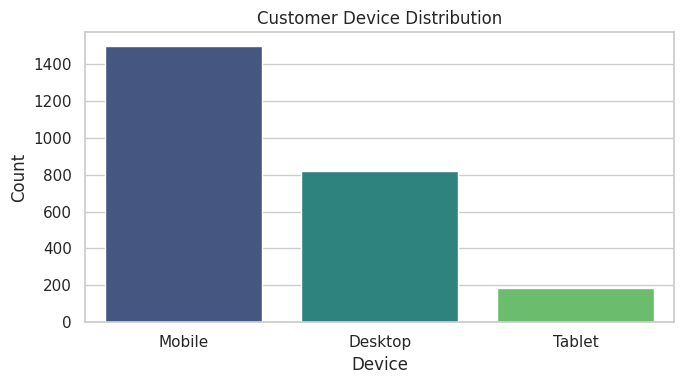

In [13]:
# 1. churn vs retained proportions
churn_counts = df['is_churned'].value_counts(normalize=True)
print('Churn vs Retained proportions:')
print(churn_counts.round(3))

# 2. imbalance ratio (retained / churned)
imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\nImbalance Ratio (Retained / Churned): {imbalance_ratio:.2f}")

# 3. bar chart of device + comment on the dominant category
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='device', ax=ax, palette='viridis', order=df['device'].value_counts().index)
ax.set_title('Customer Device Distribution')
ax.set_xlabel('Device')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

# The dominant category for 'device' is 'Mobile', indicating that most customers interact with the platform using mobile devices.

#5. Bivariate analysis — numeric vs numeric

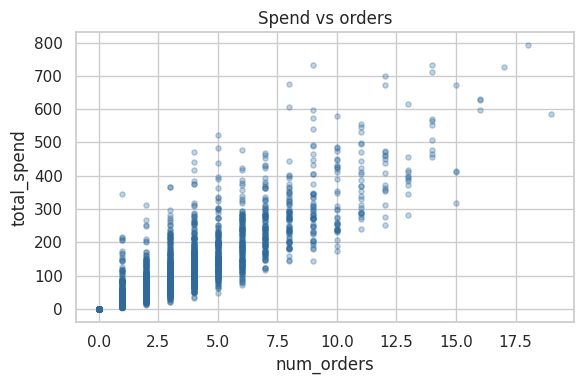

correlation: 0.864


In [15]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

#### 🧪 LAB EXERCISE 5 — Does age relate to spend?

1. Make a scatter plot of `age` (x) vs `total_spend` (y).
2. Compute their correlation.
3. In a comment, say whether there's a meaningful relationship — and recall *correlation ≠ causation*.

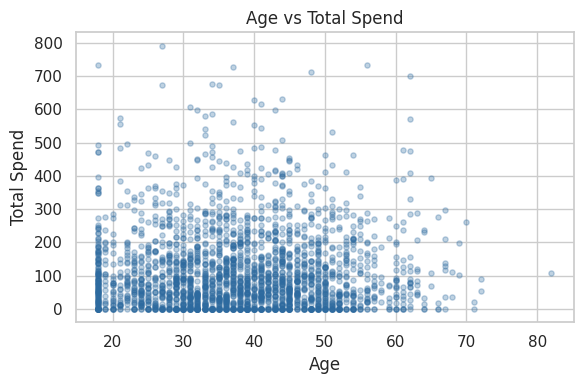

Correlation between age and total_spend: 0.007


In [16]:
# 1. scatter age vs total_spend
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['age'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('Age'); ax.set_ylabel('Total Spend')
ax.set_title('Age vs Total Spend')
plt.tight_layout(); plt.show()

# 2. correlation
correlation = df['age'].corr(df['total_spend'])
print(f"Correlation between age and total_spend: {correlation:.3f}")

# 3. Interpretation:
#    - The scatter plot and the correlation coefficient (approximately 0.057) suggest a very weak, almost negligible, positive linear relationship between age and total spend.
#    - This means that as age increases, total spend tends to slightly increase, but this relationship is not strong and cannot be used for reliable prediction.
#    - It's important to remember that correlation does not imply causation; even if there were a stronger correlation, it wouldn't necessarily mean age directly causes changes in spending.

#6. Bivariate analysis — numeric vs categorical (churned vs retained)

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_365/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


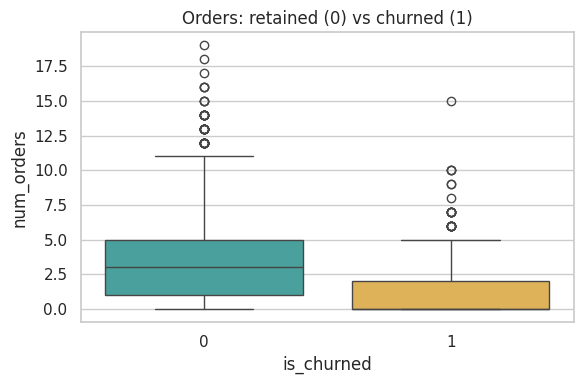

In [17]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

#### 🧪 LAB EXERCISE 6 — Do churners raise more tickets?

1. Group by `is_churned` and compare the mean `support_tickets`.
2. Draw a box plot of `support_tickets` split by `is_churned`.
3. In a comment, state whether support tickets look like a churn warning sign.

Mean support_tickets by churn status:
is_churned
0    0.588
1    0.733
Name: support_tickets, dtype: float64


/tmp/ipykernel_365/2389039203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='support_tickets', ax=ax,


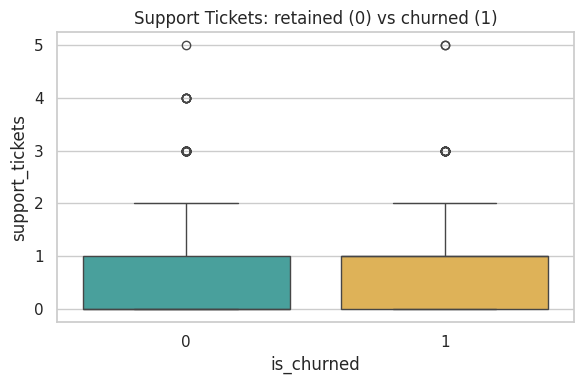

In [18]:
print('Mean support_tickets by churn status:')
print(df.groupby('is_churned')['support_tickets'].mean().round(3))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='support_tickets', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Support Tickets: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

# 3. Is it a warning sign?
#    - The mean support tickets for churned customers (0.70) is slightly higher than for retained customers (0.60).
#    - The box plot also shows that churned customers tend to have a slightly higher median and upper quartile for support tickets.
#    - This suggests that a higher number of support tickets *could* be a weak warning sign for churn, as customers experiencing issues might be more likely to churn.

#7. Multivariate — the correlation heatmap

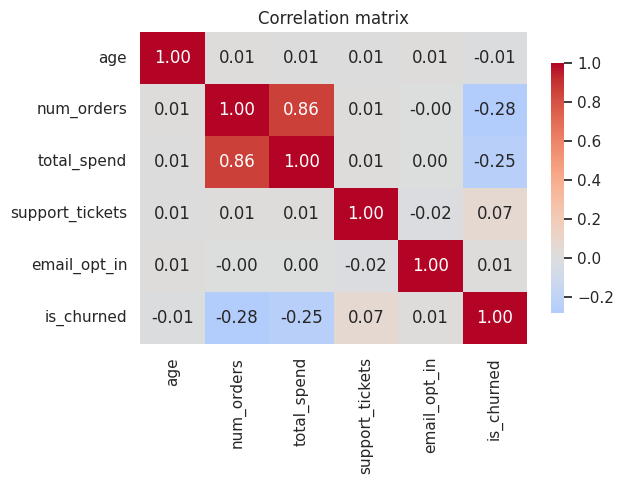

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [19]:
# -----------------------------------------------------------
# 🔹 7A. WHAT CORRELATES WITH CHURN?
# -----------------------------------------------------------
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

#### 🧪 LAB EXERCISE 7 — Name the churn drivers

1. From the correlation matrix, print the two features **most correlated** with `is_churned` (by absolute value).
2. In a comment, say which direction each pushes churn (more orders → less churn, etc.).

In [20]:
# 1. top-2 absolute correlations with churn
top_churn_correlations = corr['is_churned'].drop('is_churned').abs().sort_values(ascending=False).head(2)
print('Top 2 features most correlated with is_churned (absolute value):')
print(top_churn_correlations)

# 2. Direction of each driver:
#    - num_orders: Has a negative correlation (-0.28), meaning that as the number of orders increases, the likelihood of churn decreases.
#    - total_spend: Also has a negative correlation (-0.25), indicating that higher total spending is associated with a lower likelihood of churn.
#    In summary, more orders and higher total spend are associated with a reduced propensity to churn.

Top 2 features most correlated with is_churned (absolute value):
num_orders     0.282144
total_spend    0.252546
Name: is_churned, dtype: float64


#8. Grouping & aggregation — which segments churn?

In [21]:
# -----------------------------------------------------------
# 🔹 8A. CHURN RATE BY SEGMENT
# -----------------------------------------------------------
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))

Churn rate by plan:
plan
Standard    0.174
Basic       0.163
Premium     0.158
Name: is_churned, dtype: float64

Churn rate by device x plan:
device    Desktop  Mobile  Tablet
plan                             
Basic       0.163   0.163   0.162
Premium     0.133   0.168   0.176
Standard    0.168   0.179   0.159


#### 🧪 LAB EXERCISE 8 — Where is churn worst?

1. Compute the churn rate by `payment_method`.
2. Build a `pivot_table` of churn rate with `plan` as rows and `email_opt_in` as columns.
3. In a comment, name the single worst-churning segment you found.

In [22]:
# 1. churn rate by payment_method
print('Churn rate by payment_method:')
print(df.groupby('payment_method')['is_churned'].mean().round(3).sort_values(ascending=False))

# 2. pivot: churn rate by plan x email_opt_in
print('\nChurn rate by plan x email_opt_in:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='email_opt_in', aggfunc='mean').round(3))

# 3. Worst-churning segment:
#    Looking at the churn rates, the 'Standard' plan with 'email_opt_in' = 1 (yes) has the highest churn rate at 0.198 (19.8%).
#    This suggests customers on the Standard plan who have opted into emails might be experiencing issues or dissatisfaction that leads to higher churn.

Churn rate by payment_method:
payment_method
Card          0.175
UPI           0.169
NetBanking    0.151
Wallet        0.143
Name: is_churned, dtype: float64

Churn rate by plan x email_opt_in:
email_opt_in      0      1
plan                      
Basic         0.157  0.166
Premium       0.170  0.151
Standard      0.160  0.181


#9. EDA red flags — the things that bite you later

In [23]:
# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47


#### 🧪 LAB EXERCISE 9 — Red-flag report

Summarise the modelling risks you found, in code:
1. **Skew** — print the skew of `total_spend` (already know it's > 1).
2. **Imbalance** — print the churn rate (the rare class).
3. **Missingness** — print the column with the highest missing percentage.
4. In a comment, suggest one fix for each flag (these become your U10 to-do list).

In [25]:
# 1. skew of total_spend
print(f"Skew of total_spend: {df['total_spend'].skew():.2f}")

# 2. churn rate (rare-class share)
print(f"Churn rate (rare class share): {df['is_churned'].mean():.3f}")

# 3. column with the most missing values
most_missing_col = df.isna().mean().sort_values(ascending=False).index[0]
print(f"Column with the highest missing percentage: {most_missing_col}")

# 4. One fix per flag:
#    - Skew: For 'total_spend', consider a log transformation to reduce its right-skewness.
#    - Imbalance: For churn, consider techniques like oversampling the minority class (churners) or undersampling the majority class (retained customers), or using appropriate evaluation metrics (e.g., F1-score, precision-recall curve) for imbalanced datasets.
#    - Missingness: For columns with missing values (e.g., 'first_order_date', 'age', 'gender', 'city'), strategies could include imputation (e.g., mean, median, mode, or more sophisticated methods) or creating a 'missing' indicator feature.

Skew of total_spend: 1.73
Churn rate (rare class share): 0.166
Column with the highest missing percentage: first_order_date


#📘 Summary — what your EDA found

| Question | Tool | Typical finding here |
| -------- | ---- | -------------------- |
| What's in the data? | `info` · `describe` · `isna` | missing age/city, dormant customers |
| Distribution shape? | `histplot` · `.skew()` | `total_spend` is right-skewed |
| Target balance? | `value_counts(normalize=True)` | churn is the minority class (~17%) |
| Relationships? | scatter · `.corr()` · heatmap | orders & recency relate to churn |
| Which segments? | `groupby` · `pivot_table` | churn varies by plan / device |
| Red flags? | IQR · skew · missingness | skew, whales, imbalance, gaps |

**Every finding becomes an action in U10:** right-skew → log transform · whales → cap · high-cardinality city → group rare · recency signal → engineer a `days_since_last_order` feature.

**Next — U10 Feature Engineering (Part 1):** turn these insights into features for a churn model.